In [1]:
import pandas as pd
import numpy as np
import glob
from datasets import Dataset
from transformers import BartTokenizer, BartForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq, GenerationConfig, EarlyStoppingCallback, pipeline
from huggingface_hub import create_repo, upload_file, HfApi
import evaluate
import nltk
import matplotlib.pyplot as plt

# Data loading

In [2]:
path = './summaries3'
all_files = glob.glob(path + "/*.csv")

li = [pd.read_csv(filename, index_col=None, header=0) for filename in all_files]
df = pd.concat(li, axis=0, ignore_index=True)

In [3]:
df.shape

(12000, 8)

In [4]:
df_unique = df.drop_duplicates(subset=["comments"])
df_unique = df_unique.dropna(subset=["summary"])

In [5]:
df_unique

,listing_id,id,date,reviewer_id,reviewer_name,comments,numerical_review,summary
0,44083784,1247777770995745032,2024-09-17,37457424,Isabelle,Benjy and Daisy are welcoming and friendly ho...,5,Benjy and Daisy are welcoming hosts who took g...
1,842682386863886869,894078169260738746,2023-05-18,2634526,Mooshir,We stayed at Ami and Chris's place for a week ...,5,"We had a great time at Ami and Chris's place, ..."
2,36967371,944837839372579049,2023-07-27,522151871,Kiera,I loved my stay at Charlotte's! She was incred...,5,"Charlotte's nocarz was clean, quiet, and perfe..."
3,678233917656738138,1046331014403181217,2023-12-14,20143279,Berk,Overall we had a great stay and enjoyed the lo...,4,The flat is centrally located but has some dra...
4,14687689,1103587336521954876,2024-03-02,250634582,Maude,The apartment was very humid and there wasn’t ...,0,"The apartment had issues with humidity, noise ..."
...,...,...,...,...,...,...,...,...
11995,2533176,304415903,2018-08-09,84309879,Lisa,Ideal family apartment or for several couples....,5,"Ideal family apartment with great city views, ..."
11996,42248601,643261788589473380,2022-06-06,5668594,Jane,Max’s flat is a hidden gem. Great location rig...,5,Max's flat is a hidden gem with a beautiful ve...
11997,8191176,163584695,2017-06-25,117022331,Jimmy,We had a nice time staying at Nass' place. The...,5,Nass' place was clean and well-equipped with e...
11998,750511789628253985,903530192398922086,2023-05-31,235891940,Francesca,What a beautiful place to stay! I really enjoy...,5,Emily's apartment is a beautiful place to stay...


# Preprocessing & dataset creation

In [6]:
def preprocess_function(examples):
    inputs = tokenizer(examples["comments"], max_length=1024, truncation=True)

    labels = tokenizer(text_target=examples["summary"], max_length=128, truncation=True)

    inputs["labels"] = labels["input_ids"]
    return inputs

In [8]:
model_name = "facebook/bart-large-cnn"

dataset = Dataset.from_pandas(df_unique)
tokenizer = BartTokenizer.from_pretrained(model_name)

tokenized_dataset = dataset.map(preprocess_function, batched=True)
train_test_ds = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
test_val_ds = train_test_ds['test'].train_test_split(test_size=0.33, seed=42)

train_dataset = train_test_ds['train']
eval_dataset = test_val_ds['train']
test_dataset = test_val_ds['test']

print(f"Train: {len(train_dataset)}")
print(f"Valid: {len(eval_dataset)}")
print(f"Test: {len(test_dataset)}")

Map:   0%|          | 0/11921 [00:00<?, ? examples/s]

Train: 9536
Valid: 1597
Test: 788


# Model finetuning

Do occeny kryterium analitycznego modelu wykorzystano metryki ROUGE, które mierzą jak bardzo wygenerowane streszczenie pokrywa się z oryginalnym teskstem:
- ROUGE-1 - (unigramy) - nakładanie się pojedynczych słów - kluczowe słowa, fakty
- ROUGE-2 - (bigramy) - nakładanie się par sąsiadujących słów - płynność tekstu
- ROUGE-L - zwraca uwagę na najdłuższy ciąg słów, który pojawia się zarówno w tekście oryginalnym jak i streszczeniu

Do obliczania metryk ROUGE wykorzystany został pakiet `evaluate` od Hugging Face i  `nltk` do tokenizacji przy obliczaniu metryk ROUGE.

In [9]:
rouge = evaluate.load("rouge")
nltk.download('punkt_tab')
nltk.download('punkt')

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    result = {k: round(v * 100, 4) for k, v in result.items()}

    prediction_lens = np.sum(predictions != tokenizer.pad_token_id, axis=1)
    result["gen_len"] = np.mean(prediction_lens)
    return result

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/vistek528/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/vistek528/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
model = BartForConditionalGeneration.from_pretrained(model_name)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./ium_bart_v3",
    per_device_train_batch_size=12,
    per_device_eval_batch_size=32,
    predict_with_generate=True,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=100,
    logging_steps=10,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=0.15,
    save_total_limit=2,
    fp16=True,
    load_best_model_at_end=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)
trainer.train()

/tmp/ipykernel_14291/2349638882.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss,Validation Loss
100,1.259300,1.217044
200,1.081800,1.205971
300,1.106100,1.180233
400,1.053300,1.141982
500,1.050900,1.163890
600,1.055000,1.107972
700,0.970000,1.103251
800,0.892500,1.075865
900,0.791800,1.078078
1000,0.843600,1.066738


/home/vistek528/IUM/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=2100, training_loss=0.8494080836432321, metrics={'train_runtime': 374.909, 'train_samples_per_second': 254.355, 'train_steps_per_second': 21.205, 'total_flos': 1.2941813239775232e+16, 'train_loss': 0.8494080836432321, 'epoch': 2.641509433962264})

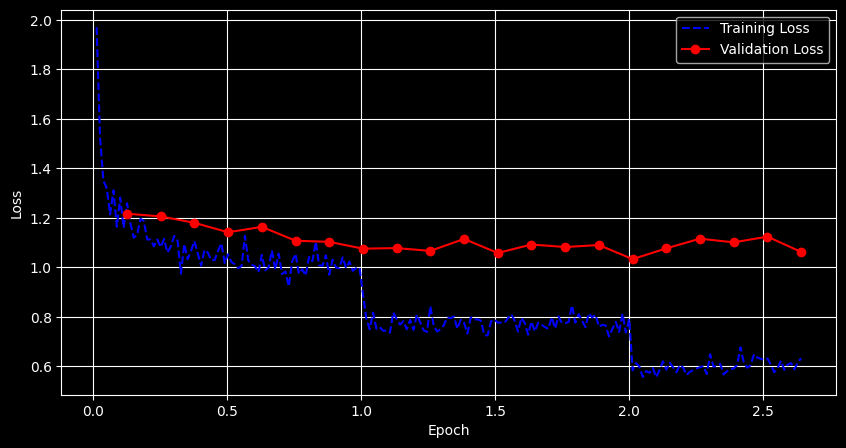

In [11]:
history_df = pd.DataFrame(trainer.state.log_history)

train_history = history_df[history_df['loss'].notna()]
eval_history = history_df[history_df['eval_loss'].notna()]


plt.figure(figsize=(10, 5))

plt.plot(train_history['epoch'], train_history['loss'], label='Training Loss', color='blue', linestyle='--')
plt.plot(eval_history['epoch'], eval_history['eval_loss'], label='Validation Loss', color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

Jak można zauważyć na przedstawionym powyżej wykresie, fine-tuning modelu `facebook/bart-large-cnn` został przeprowadzony poprawnie. Po ok. 2.5 epokach od początku treningu został on przerwany, aby przeciwdziałać nadmiernemu dopasowaniu modelu. Model `facebook/bart-large-cnn` został wytrenowany na sporym zbiorze danych i wielkość zbioru danych wykorzystywanego do fine tuningu (ok. 12 tys. recenzji i streszczeń) jest niewystarczający do pełnej generalizacji i wychwycenia wszystkich wzorców, szczególnie dla tak rozbudowanego modelu. Niemniej jednak spadek wartości funkcji straty w kolejnych krokach treningu pokazuje, że choć z trudnościami, to jednak model przyswoił pewną wiedzę.

In [12]:
model.save_pretrained("ium_bart_final_v3")
tokenizer.save_pretrained("ium_bart_final_v3")

('ium_bart_final_v3/tokenizer_config.json',
 'ium_bart_final_v3/special_tokens_map.json',
 'ium_bart_final_v3/vocab.json',
 'ium_bart_final_v3/merges.txt',
 'ium_bart_final_v3/added_tokens.json')

In [14]:
bart_summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
custom_summarizer = pipeline("summarization", model="./ium_bart_final_v3", tokenizer="./ium_bart_final_v3")

text = "We've been really comfortable at Susan's home. The location is quite suitable for a some days-week escape. As we were seven people, the house was perfect for us. The metro station is two minuts close to the house and in half an hour you'll be in the city center. There are some interesting parks around to enjoy fresh air."
summary = custom_summarizer(
    text,
    max_length=100,
    min_length=20,
    do_sample=False
)

bart_summary = bart_summarizer(
    text,
    max_length=50,
    min_length=20,
    do_sample=False
)

ium_model_summary = summary[0]['summary_text']
bart_summary = bart_summary[0]['summary_text']

print("Liczba słów w streszczeniach")
print(f"Oryginalny tekst: {len(text.split())}")
print(f"{model_name}: {len(bart_summary.split())}")
print(f"IUM Bart: {len(ium_model_summary.split())}")
print(f"Oryginalny tekst:\n{text}")
print("\nStreszczenia:")
print(f"\n{model_name}")
print(bart_summary)
print("\nIUM Bart:")
print(ium_model_summary)

Device set to use cuda:0
/home/vistek528/IUM/venv/lib/python3.12/site-packages/transformers/models/bart/configuration_bart.py:177: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(
Device set to use cuda:0
Your max_length is set to 100, but your input_length is only 73. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=36)


Liczba słów w streszczeniach
Oryginalny tekst: 59
facebook/bart-large-cnn: 30
IUM Bart: 14
Oryginalny tekst:
We've been really comfortable at Susan's home. The location is quite suitable for a some days-week escape. As we were seven people, the house was perfect for us. The metro station is two minuts close to the house and in half an hour you'll be in the city center. There are some interesting parks around to enjoy fresh air.

Streszczenia:

facebook/bart-large-cnn
The location is quite suitable for a some days-week escape. The metro station is two minuts close to the house. There are some interesting parks around to enjoy fresh air.

IUM Bart:
Susan's home was perfect for a days-week escape, with a great location and amenities.


Jak widać streszczenie wygenerowane przez dotrenowany model jest krótsze od streszczenia wygenerowanego przez oryginalny model, a przy tym zachowuje najważniejsze informacje zawarte w recencji.

# Export to huggingface

In [15]:
api = HfApi()
repo_id = "VisteK528/facebook-bart-cnn-ium-v3"
api.create_repo(repo_id=repo_id, exist_ok=True)
api.upload_folder(
    folder_path="./ium_bart_final_v3",
    repo_id=repo_id,
    repo_type="model"
)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/VisteK528/facebook-bart-cnn-ium-v3/commit/e5748c053c328fe57713085adbbe04d79db2d724', commit_message='Upload folder using huggingface_hub', commit_description='', oid='e5748c053c328fe57713085adbbe04d79db2d724', pr_url=None, repo_url=RepoUrl('https://huggingface.co/VisteK528/facebook-bart-cnn-ium-v3', endpoint='https://huggingface.co', repo_type='model', repo_id='VisteK528/facebook-bart-cnn-ium-v3'), pr_revision=None, pr_num=None)

In [16]:
custom_summarizer = pipeline("summarization", model="VisteK528/facebook-bart-cnn-ium-v3", tokenizer="VisteK528/facebook-bart-cnn-ium-v3")

text = "Tim and Pippa are lovely, so welcoming and friendly. It’s an excellent location for getting into town as it’s just around the corner from the tube. They also provided a great breakfast with homemade jam! Things to note are a comfy bed and great private bathroom. We’re looking forward to going back to stay next week!"
summary = custom_summarizer(
    text,
    max_length=100,
    min_length=20,
    do_sample=False
)

out = summary[0]['summary_text']

print(len(text.split()))
print(len(out.split()))

print(text)
print(out)

config.json: 0.00B [00:00, ?B/s]

/home/vistek528/IUM/venv/lib/python3.12/site-packages/transformers/models/bart/configuration_bart.py:177: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

Device set to use cuda:0
Your max_length is set to 100, but your input_length is only 76. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=38)


56
19
Tim and Pippa are lovely, so welcoming and friendly. It’s an excellent location for getting into town as it’s just around the corner from the tube. They also provided a great breakfast with homemade jam! Things to note are a comfy bed and great private bathroom. We’re looking forward to going back to stay next week!
Tim and Pippa's place is an excellent location for getting into town, with a great breakfast and welcoming hosts.


In [17]:
def get_rouge_scores(model_path, test_ds, name):
    eval_model = BartForConditionalGeneration.from_pretrained(model_path)
    gen_config = GenerationConfig(
        max_length=142,
        min_length=56,
        num_beams=4,
        early_stopping=True,
        no_repeat_ngram_size=3,
        forced_bos_token_id=0,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        decoder_start_token_id=eval_model.config.decoder_start_token_id or 2
    )


    eval_model.generation_config = gen_config

    eval_model.config.max_length = 142
    eval_model.config.min_length = 56
    eval_model.config.num_beams = 4

    eval_args = Seq2SeqTrainingArguments(
        output_dir="./temp_eval",
        per_device_eval_batch_size=16,
        predict_with_generate=True,
        fp16=True,
    )

    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=eval_model)
    trainer = Seq2SeqTrainer(
        model=eval_model,
        args=eval_args,
        train_dataset=None,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    metrics = trainer.evaluate()
    return {
        "Model": name,
        "ROUGE-1": metrics["eval_rouge1"],
        "ROUGE-2": metrics["eval_rouge2"],
        "ROUGE-L": metrics["eval_rougeL"],
        "Gen Len": metrics["eval_gen_len"]
    }

try:
    ium_results = get_rouge_scores("./ium_bart_final_v2", test_dataset, "IUM BART (Fine-tuned)")
    ium_results2 = get_rouge_scores("./ium_bart_final_v3", test_dataset, "IUM BART (Fine-tuned) v3")
    base_results = get_rouge_scores("facebook/bart-large-cnn", test_dataset, "Facebook BART (Base)")

    df_results = pd.DataFrame([base_results, ium_results, ium_results2])
    display(df_results)
except Exception as e:
    print(e)

/home/vistek528/IUM/venv/lib/python3.12/site-packages/transformers/models/bart/configuration_bart.py:177: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(
/tmp/ipykernel_14291/3739053314.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


/home/vistek528/IUM/venv/lib/python3.12/site-packages/transformers/models/bart/configuration_bart.py:177: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(
/tmp/ipykernel_14291/3739053314.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


/tmp/ipykernel_14291/3739053314.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


,Model,ROUGE-1,ROUGE-2,ROUGE-L,Gen Len
0,Facebook BART (Base),28.2967,10.2403,21.5008,64.752538
1,IUM BART (Fine-tuned),35.4365,16.5681,27.7958,60.888325
2,IUM BART (Fine-tuned) v3,35.5547,16.6670,28.0250,60.539340


Jak widać obliczone metryki ROUGE dla zbioru testowego przez model oryginalny `facebook/bart-large-cnn` były niższe od tych obliczonych dla modeli wytrenowanych w ramach projektu. Wyższa wartość wskaźnika ROUGE-1 oznacza, że w streszczeniach modeli przygotowanych na potrzeby projektu pojawiło się więcej słów z przykładu streszczenia. Tak samo szyk wygenerowanych streszczeń mocniej przypominał przykładowe streszczenie, o czym świadczy ROUGE-2, który pokazuje liczbę sąsiadujących par słów (bigramów) występujących zarówno w oryginalnym tekście jak i recenzji. Ostatecznie wskaźnik ROUGE-L, który mierzy najdłuższy ciąg słów występujący zarówno w przykładzie streszczenia, jak i w wygenerowanym streszczeniu był najwyższy dla modeli po fine-tuningu. Należy zwrócić także uwagę, że streszczenia generowane przez autorskie modele były średnio o ok. 4 tokeny krótsze od tych generowanych przez oryginalny model, przekazujac średnio więcej treści.